Joyce Wang

Referred to: 
- Tutorial: https://nbisweden.github.io/workshop-scRNAseq/labs/scanpy/scanpy_05_dge.html#meta-dge_gsa
- GSEApy documentation with tutorial: https://gseapy.readthedocs.io/en/latest/gseapy_example.html#Assign-prerank()-with
- GSEApy Github: https://github.com/zqfang/GSEApy
- General information about gene set enrichment and pathway analysis for single-cell: https://www.sc-best-practices.org/conditions/gsea_pathway.html

# Gene Set Enrichment Analysis with GSEApy

In [1]:
# pip install gseapy

In [2]:
# Core libraries
import hisepy
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt
import seaborn as sns

from gseapy import dotplot

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/VertexPartition.py:413: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\frac{1}{m} \\sum_{ij} \\left(A_{ij} - \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/VertexPartition.py:788: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\sum_{ij} \\left(A_{ij} - \\gamma \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/Optimiser.py:27: SyntaxWarning: invalid escape sequence '\g'
  implementation therefore does not guarantee subpartition :math:`\gamma`-density.
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/Optimiser.py:346: SyntaxWarning: invalid escape sequence '\s'
  .. math:: Q = \sum_k \\lambda_k Q_k.


# Load in data

In [3]:
h5ad_files = hisepy.cache_fileset('f48bf688-1a5f-456c-b0b0-c6ec870ec003')

In [4]:
# creating a list
adata_list = []

# looping through the file names
for h5ad_file in h5ad_files:
    #read the file into an AnnData object using scanpy
    adata = sc.read_h5ad(h5ad_file)
    #appending the AnnData file into the list
    adata_list.append(adata)

In [5]:
# using anndata to concatenate: code chunk from Scanpy tutorial

# combine multiple anndata objects and adds a "sample" column telling you which dataset each cell came from; aka, which DRUG NAME each cell was treated with!
adata = ad.concat(adata_list, label="sample")

# make sure all observations are unique
adata.obs_names_make_unique()

# filter out CD8aa because there aren't enough!
adata = adata[adata.obs.AIFI_L2 != "CD8aa"]

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/anndata/_core/merge.py:1667: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(


In [6]:
# len(adata_list) for how many files are in the list: 18, for 8 drugs with 2 formulas each and 2 controls
print(f"Length of adata_list is {len(adata_list)}")

adata

Length of adata_list is 18


View of AnnData object with n_obs × n_vars = 449975 × 1916
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2', 'sample'
    obsm: 'X_pca', 'X_umap'

**The data contains 25,000 cells per sample, 18 samples (for 8 drugs with 2 formulas each and 2 controls), 450,000 observations (total cells), and 1,916 measured genes.**

# Cleaning up labels and color-coordinating drugs

Removing accession numbers/IDs from the drug names for the sake of presentation figures. Making sure the second word in a drug treatment name is lowercase. Reordering the drug treatments so the controls appear first in figures. Color-coordinating drugs when it might be needed for visualization purposes.

In [7]:
import re

unique_drug_names = adata.obs['drug_name'].unique()

def clean_name(name):
    name = re.sub(' \\(.*\\) ', ' ', name)
    name = re.sub(' \\(.*\\)$', '', name)
    name = name.replace("IL6 Control", "IL-6 control")
    name = re.sub(r' [A-Z]', lambda match: match.group(0).lower(), name)
    return name

# for name in unique_drug_names:
    # print(clean_name(name))

adata.obs['clean_drug_name'] = adata.obs['drug_name'].copy().apply(clean_name)

# .map(clean_mapping)

/tmp/ipykernel_1182/2774628550.py:15: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['clean_drug_name'] = adata.obs['drug_name'].copy().apply(clean_name)


In [8]:
#getting the two controls
controls = ["IL-6 control", "DMSO control"]

#make sure the drug names are categorical
adata.obs["clean_drug_name"] = (
    adata.obs["clean_drug_name"].astype("category")
)

#getting the current drug treatment order
drugs = list(adata.obs["clean_drug_name"].cat.categories)

#move control labels to the front and keep the rest in their original order
others = [c for c in drugs if c not in controls]
new_order = controls + others

# apply the new order
adata.obs["clean_drug_name"] = (
    adata.obs["clean_drug_name"].cat.reorder_categories(new_order, ordered=True)
)

In [9]:
# Make a dictionary to match drug names to colors
drug_color_dict = {
    'Afatinib': '#135669',
    'Afatinib dimaleate': '#3a728d',
    'Baricitinib': '#b35100',
    'Baricitinib phosphate': '#fb6f00',
    'Canertinib': '#d593c7',
    'Canertinib dihydrochloride': '#fcb0ef',
    'DMSO control': '#818689',
    'Erlotinib': '#208bbd',
    'Erlotinib hydrochloride': '#bad5e3',
    'Gefitinib': '#7030a0',
    'Gefitinib hydrochloride': '#9382d4',
    'IL-6 control': '#51d4c7',
    'NVP-BSK805': '#d4c300',
    'NVP-BSK805 2HCl': '#fadf80',
    'Ruxolitinib': '#008f00',
    'Ruxolitinib phosphate': '#92d051',
    'Tofacitinib': '#c90000',
    'Tofacitinib citrate': '#fd7a69'
}

# Make sure the type is categorical for the column we want to color by
adata.obs['clean_drug_name'] = adata.obs['clean_drug_name'].astype('category')

# Make a list of colors that matches the order of categories
color_list = [drug_color_dict[drug_name] for drug_name in adata.obs['clean_drug_name'].cat.categories]

# Add the list to uns['<column_name>_colors']
adata.uns['clean_drug_name_colors'] = color_list

# Normalization

In [10]:
# Preserve raw counts of [cells x genes] by making a copy of adata.X and calling it the "counts" layer
adata.layers["counts"] = adata.X.copy()

# Normalize counts of [cells x genes] adata.X (rescale each cell to a specific library size)
sc.pp.normalize_total(adata, target_sum = 1e4)

# Apply log-transform to adata.X, so it's normalized and logged
sc.pp.log1p(adata)

# Make a copy of adata.X, call it the "log_transformed" layer, which is normalized and logged
adata.layers["log_transformed"] = adata.X.copy()

# DEGs

In [11]:
detection_cutoff = 0.02

# making a dictionary of subsetted data where the key is the cell type, and the value is the anndata object with DE results inside
subsets_cells = {}

for cell_type in adata.obs['AIFI_L2'].unique():  # looping through cell types
    cell_type_subset = adata[adata.obs.AIFI_L2 == cell_type].copy()

    min_cells = int(cell_type_subset.shape[0] * detection_cutoff)

    # filter genes to keep only those that are expressed in 2% or more of the cells for each cell type before DEG tests
    sc.pp.filter_genes(
        cell_type_subset,
        min_cells = min_cells
    )

    # run differential expression
    sc.tl.rank_genes_groups(
        adata = cell_type_subset,
        groupby = "clean_drug_name", # drug treatments compared against the DMSO negative control
        reference = "DMSO control",
        method = "wilcoxon", # Scanpy's Wilcoxon rank-sum test
        layer = "log_transformed" # log-normalized expression
    )
    subsets_cells[cell_type] = cell_type_subset #store each cell type specific DE result in a dictionary

# print(subsets_cells)

# figure out grabbing the data frames from these -- adata.to_df()

# get_rank

In [12]:
# for cell_type, subset_cell in subsets_cells.items():    
    # print(cell_type)
    # sc.pl.rank_genes_groups_dotplot(subset_cell, groupby="clean_drug_name", n_genes=5)

Trying to make sense of the above dot plots, it at first seemed like the columns are repeating information since the reference is only ever the DMSO control. It seems like this is actually picking out the top 5 differentially expressed genes against the reference for each treatment, and is *then* showing the levels those genes are expressed across **all** of the treatments.

**Note:** In the drug treatment vs. DMSO control GSEA notebooks (`gseapy_Hallmark_JW.ipynb`, `gseapy_KEGG_JW.ipynb`, `gseapy_Reactome_JW.ipynb`), I manually read in the data, cleaned up the labels, normalized the data, and performed DGE for the purpose of showing the steps of differential gene expression analysis in scanpy. **These results are the same as Sean's DEG results csv files uploaded onto HISE.** In the head-to-head formulation comparisons GSEA notebooks (`gseapy_head_to_head_Hallmark_JW.ipynb`, `gseapy_head_to_head_KEGG_JW.ipynb`, `gseapy_head_to_head_Reactome_JW.ipynb`), I show the process of loading in the DEG results csv from HISE and performed GSEA after.

# Gene Set Enrichment Analysis using GSEApy

**Note: We are looking at *each* drug (`drug_name`) vs. DMSO neg. control (the reference) for *each* cell type (AIFI_L2)**.

Why run GSEA after DEG?: “On the aggregate level, like running GSEA after differential gene expression tests, we can check for enrichment of pathways for the whole set of cells we used to generate the DEGs, which is quite useful.”

# Gene set `KEGG_2019_Human`

## Extract DEG results into ranked genes using `prerank()`

We need a table with all DEGs and their log foldchanges. However, many lowly expressed genes will have high foldchanges and just contribue noise, so also filter for expression in enough cells.

`sc.get.rank_genes_groups_df(subset_cell, group=drug)` returns a nice table with `names` (DEG names), `scores`, `logfoldchanges`, `pvals_adj`, etc...

For each drug vs. DMSO, extract a ranked gene list with GENE and RANK_METRIC.

In [13]:
### Add a dict to store results
gsea_res = {}

for cell_type, subset_cell in subsets_cells.items():
    ### Nested dict to store each drug
    gsea_res[cell_type] = {}
    
    # adapted from tutorial linked above: calculate_qc_metrics will calculate number of cells per gene
    sc.pp.calculate_qc_metrics(subset_cell, percent_top=None, log1p=False, inplace=True)

    # list of drug "groups"
    deg = subset_cell.uns["rank_genes_groups"]
    drugs = deg["names"].dtype.names

    for drug in drugs:
        if drug == "DMSO control":
            continue # skip reference condition

        # adapted from tutorial linked above: extract ranked genes (names + logFC)
        gene_rank = sc.get.rank_genes_groups_df(
            subset_cell,
            group = drug,
            key = 'rank_genes_groups')[['names','logfoldchanges']]
    
        # adapted from tutorial above: Filtering out the gene sets with low number of genes -> filter for genes expressed in at least 30 cells
        # gene_rank = gene_rank[gene_rank["names"].isin(
            # subset_cell.var_names[subset_cell.var.n_cells_by_counts > 30]
        # )] # don't need because already filter genes to keep only those that are expressed in 2% or more of the cells for each cell type before DEG tests

        ### Sort the genes from high to low fold changes
        gene_rank = gene_rank.sort_values('logfoldchanges', ascending = False)
        
        # adapted from multiple tutorials: Run prerank GSEA directly with gp.prerank()
        pre_res = gp.prerank(
            rnk = gene_rank,
            gene_sets = "KEGG_2019_Human", # Could also download gene sets from: Msigdb hallmark gene sets, Reactome, etc...
            # default min_size = 15 -- note, number of features is reduced already by limited gene panel
            outdir = None, # don't write to disk
            verbose = False # make True to see what's going on behind the scenes
        )
        
        ### Store the output in our nested dict
        gsea_res[cell_type][drug] = pre_res

## View results for each cell type and drug, in a table:

In [14]:
# View results for each cell type and drug name:

# Note: CD4 Naive cell type and IL-6 control shown here: expect JAK/STAT pathway to be enriched b/c of IL-6 stimulating it in the control
pre_res = gsea_res['CD4 Naive']['IL-6 control']
pre_res.res2d.sort_values('FDR q-val').head(10)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,"Parathyroid hormone synthesis, secretion and a...",-0.674184,-1.835734,0.0,0.067903,0.048,8/20,14.42%,BCL2;GATA3;MAP2K1;GNA11;PLCB3;RXRA;PRKACA;MAPK3
2,prerank,Amoebiasis,-0.59857,-1.561096,0.028409,0.495439,0.396,10/17,23.89%,ARG2;PIK3CD;GNA11;PLCB3;PRKACA;ITGB2;PIK3CB;NF...
24,prerank,Rheumatoid arthritis,-0.46463,-1.247212,0.159292,0.558118,0.913,5/17,13.14%,IL23A;ITGAL;CTSL;LTB;ITGB2
23,prerank,Apelin signaling pathway,-0.424784,-1.24862,0.129129,0.59876,0.91,9/26,20.22%,SMAD3;PIK3CG;MAP2K1;PLCB3;PRKACA;MAPK3;SMAD2;C...
17,prerank,GnRH signaling pathway,-0.453624,-1.29846,0.115265,0.607352,0.858,8/25,14.42%,MAP3K1;MAPK13;MAPK14;MAP2K1;GNA11;PLCB3;PRKACA...
14,prerank,Adrenergic signaling in cardiomyocytes,-0.489557,-1.31772,0.131498,0.612854,0.846,9/21,14.93%,PIK3CG;MAPK13;BCL2;MAPK14;PLCB3;PPP2R5A;PRKACA...
28,prerank,Phospholipase D signaling pathway,-0.405777,-1.209939,0.17608,0.630077,0.94,8/28,17.58%,PIK3CG;PIK3CD;MAP2K1;RALGDS;PLCB3;FYN;MAPK3;PI...
21,prerank,Vascular smooth muscle contraction,-0.472786,-1.250498,0.178161,0.645419,0.908,7/17,18.17%,MAP2K1;GNA11;PLCB3;PRKACA;MAPK3;PRKCH;CALM3
13,prerank,Oxytocin signaling pathway,-0.454452,-1.330123,0.110092,0.653519,0.831,9/25,18.86%,PIK3CG;MAP2K1;PLCB3;PRKACA;MAPK3;NFATC3;NFATC1...
20,prerank,Ras signaling pathway,-0.380883,-1.264924,0.124528,0.65916,0.896,17/50,23.12%,LAT;REL;PIK3CD;FLT3LG;MAP2K1;RALGDS;FOXO4;PRKA...


### **FDR q-vals are not good.**
- **Problem w/ FDR q-vals:** we don't have the full set of genes in the probe set (only selected ~1900 genes) --> could lead to bad FDR q-vals (not a lot of genes are being picked up, so they're not being ranked very well). We can blame this on the small transcriptome panel in our experiment.

## Heatmap 1) Multi-pathway visualization: Heatmap for normalized enrichment scores (NES) for each cell type, drugs x (selected) pathways.
- For each cell type:
     - NES as values
     - drug names on one axis
     - pathways on the other axis
- Across drugs, which pathways are consistently activated or suppressed in a given cell type (against the DMSO control)?
- Positive NES -> pathway activated against DMSO
- Negative NES -> pathway suppressed against DMSO

In [15]:
# Get all pathway names
kegg_pathways = pre_res.res2d["Term"].values
# print(kegg_pathways)

In [16]:
# Select pathways of interest, related to immune responses:
selected_pathways = [
    "JAK-STAT signaling pathway",
    "TNF signaling pathway",
    "NF-kappa B signaling pathway",
    "Rheumatoid arthritis"
]

heatmap1_records = []

for cell_type, drug_dict in gsea_res.items():
    for drug, pre_res in drug_dict.items():
        res = pre_res.res2d # results in rows with columns like Term, NES, FDR q-val, etc...

        for pathway in selected_pathways:
            if pathway in res["Term"].values:
                # Extract the NES value using labels (loc); from the rows where the pathway matches, return the NES column as nes
                nes = res.loc[res["Term"] == pathway, "NES"].values[0]
            else:
                nes = float("nan")  # pathway not enriched/not present in table
                
            heatmap1_records.append({
                "cell_type": cell_type,
                "drug": drug,
                "pathway": pathway,
                "NES": nes
            })

# Create dataframe
heatmap1_nes_df = pd.DataFrame(heatmap1_records)

# Change KEGG JAK/STAT pathway name from JAK-STAT to JAK/STAT
heatmap1_nes_df["pathway"] = heatmap1_nes_df["pathway"].replace({"JAK-STAT signaling pathway":
        "JAK/STAT signaling pathway"})

In [17]:
# Original heatmap before adding in annotations for significantly enriched NES values:

# cell_types = heatmap1_nes_df["cell_type"].unique()

# # Loop through each cell type, and plot a heatmap
# for cell_type in cell_types:
    
#     # Pivot the data for this cell type
#     heatmap1_data = heatmap1_nes_df[
#         heatmap1_nes_df["cell_type"] == cell_type
#     ].pivot(
#         index="pathway",   # rows = pathways
#         columns="drug",    # columns = drugs
#         values="NES"       # values = NES
#     )

#     # Create the figure
#     plt.figure(figsize=(len(heatmap1_data.columns)*0.8, 6)) # width scales with # of drugs
    
#     sns.heatmap(
#         heatmap1_data,
#         cmap="RdBu_r",      # Red = positive NES, Blue = negative NES
#         center=0,           # Center colormap at 0
#         linewidths=0.5,
#         cbar_kws={"label": "Normalized Enrichment Score (NES)"}
#     )

#     plt.title(f"NES for selected pathways, zooming into: {cell_type}")
#     plt.ylabel("Pathway")
#     plt.xlabel("Drug")
#     plt.xticks(rotation=45, ha="right")
#     plt.tight_layout()
#     plt.show()

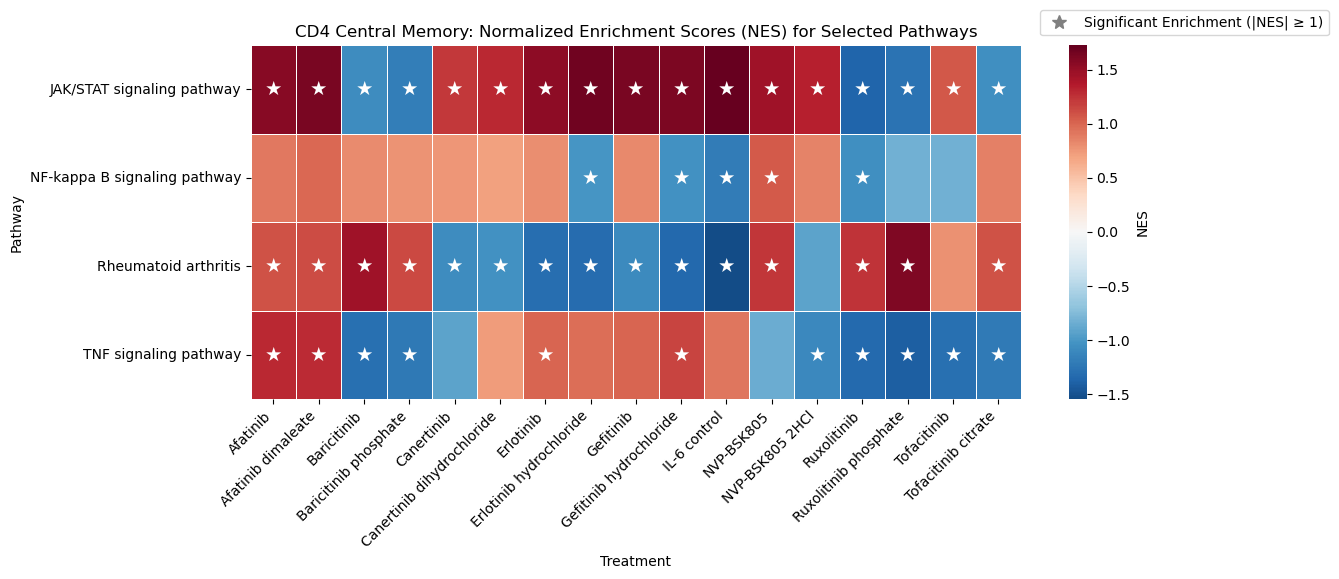

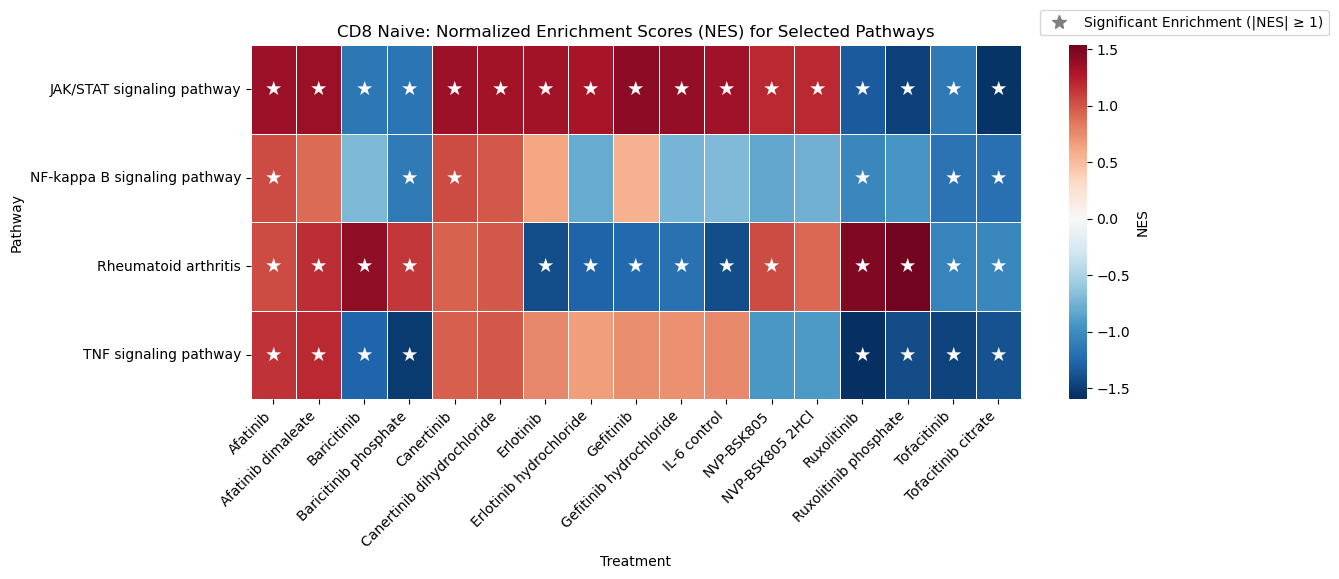

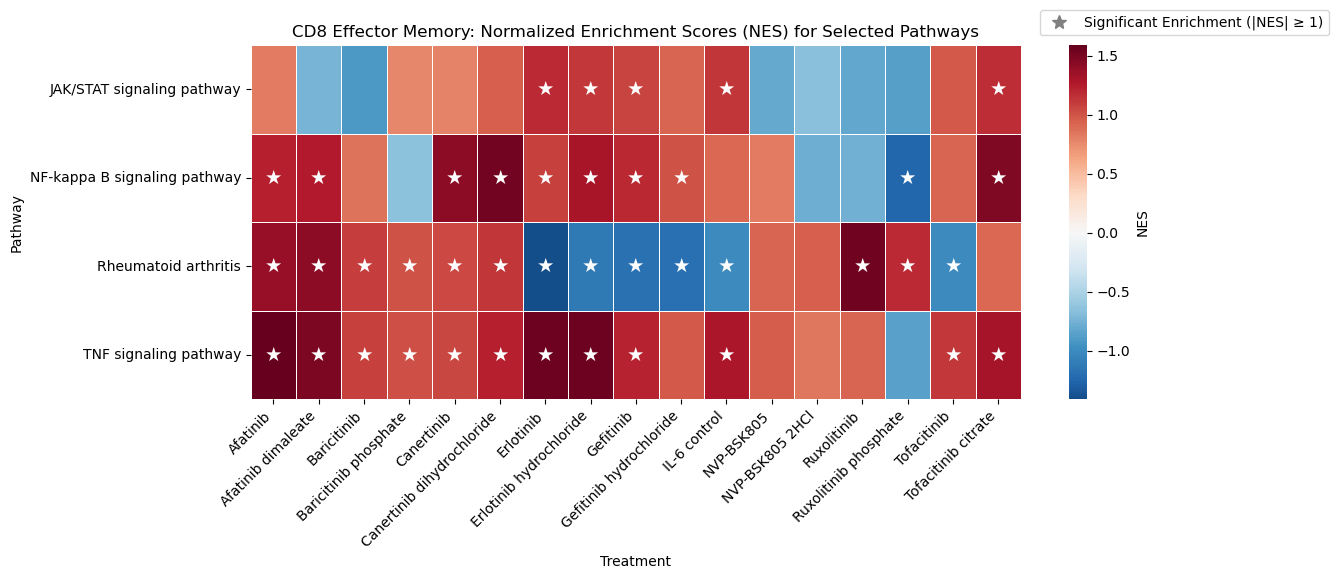

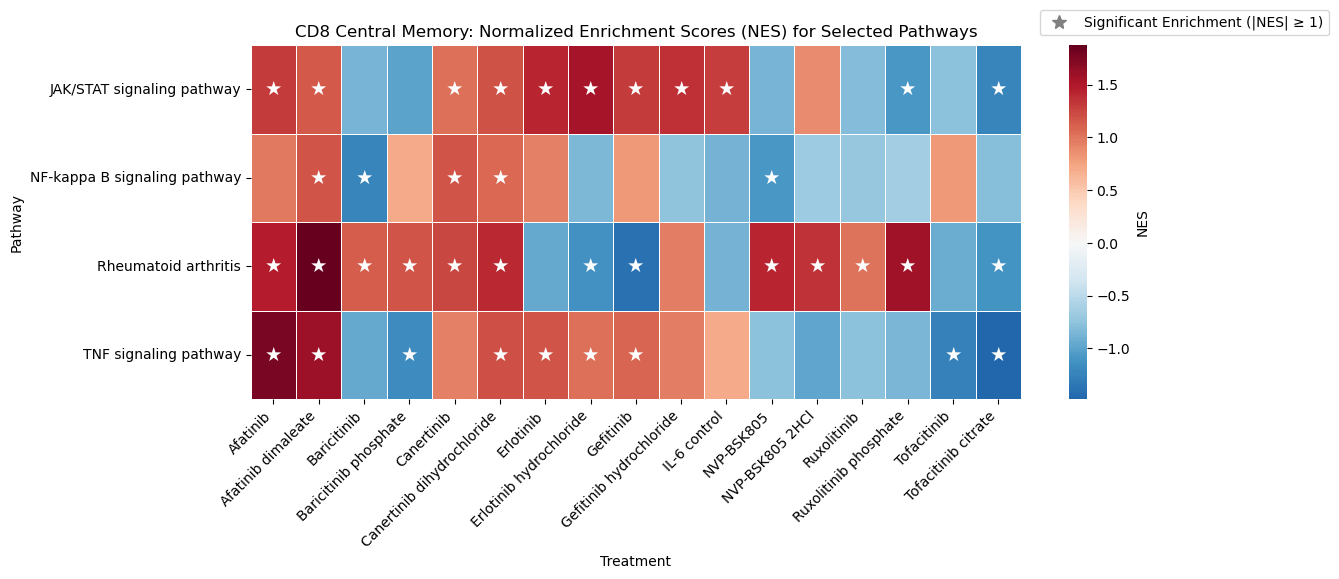

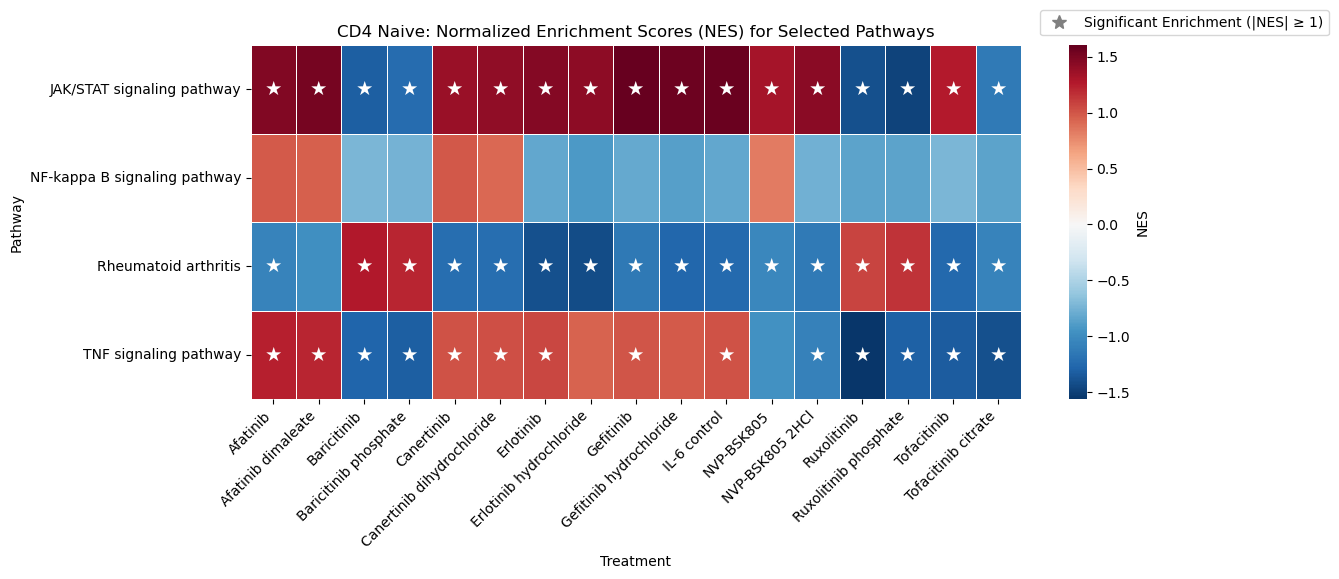

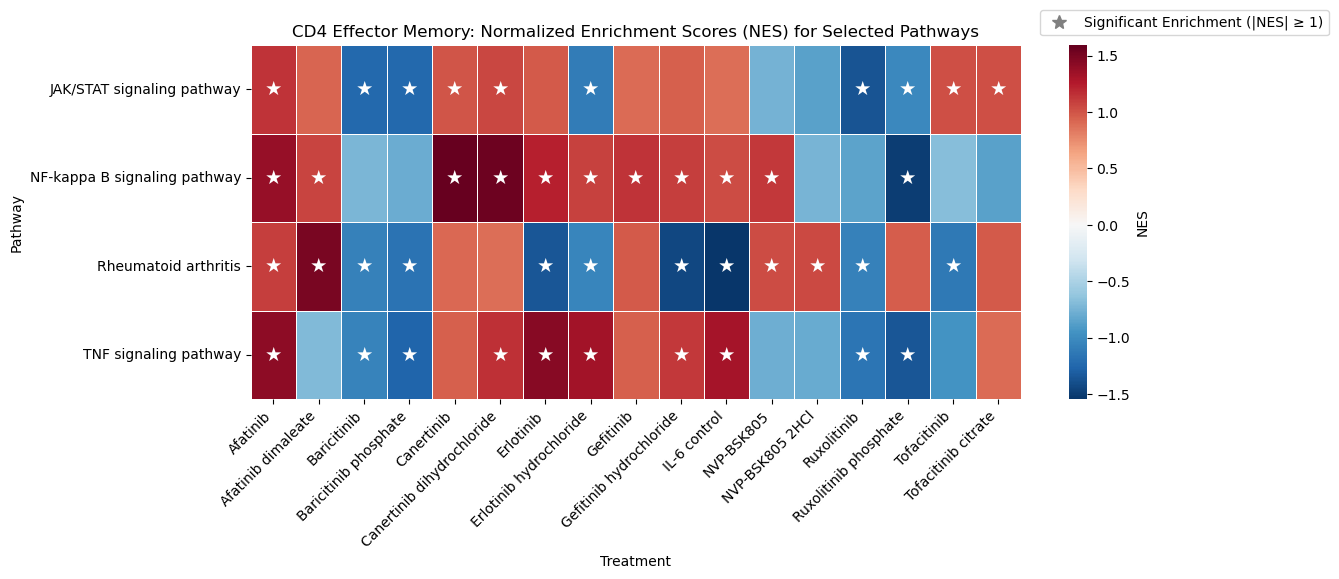

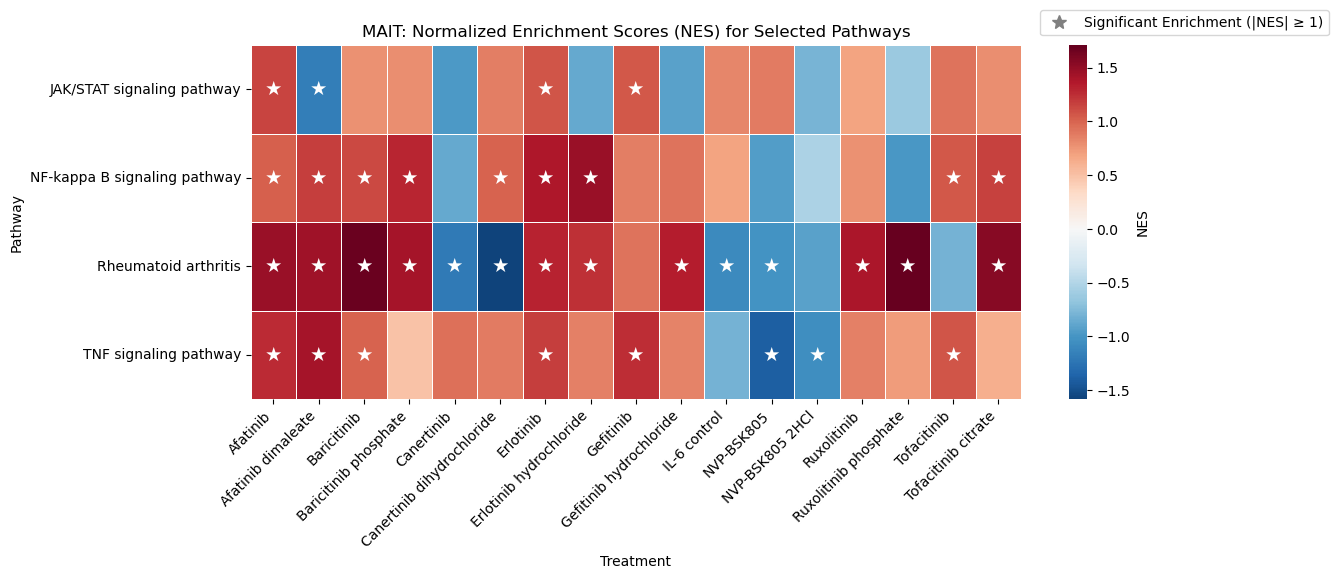

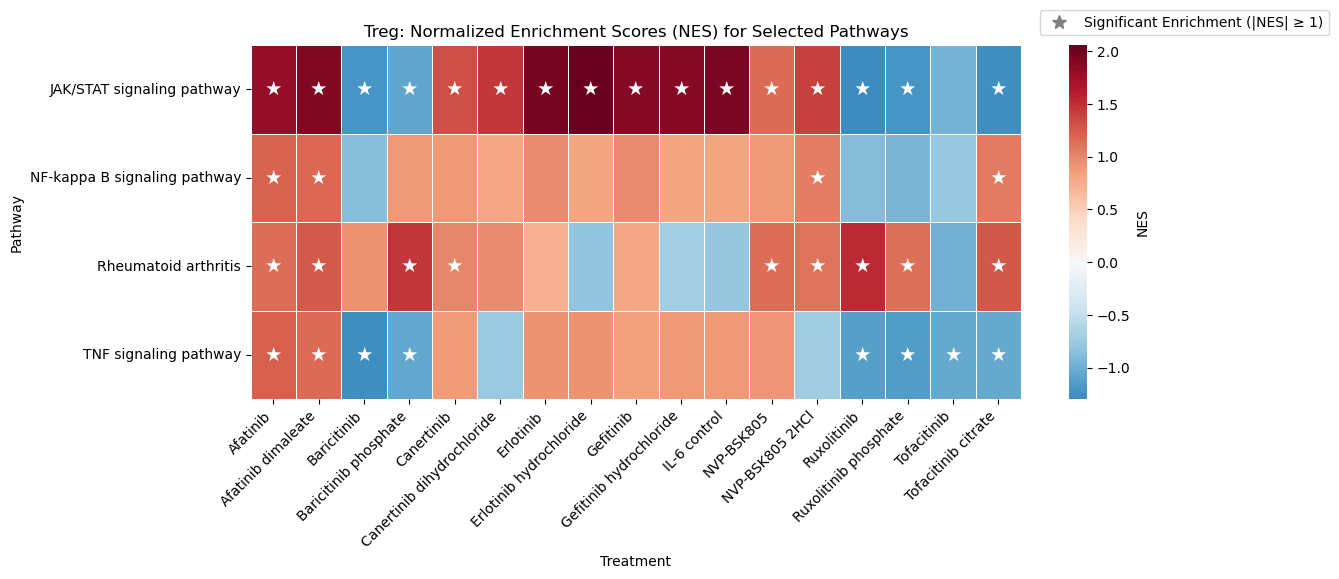

In [18]:
# starred cells for significantly enriched NES values:

from matplotlib.lines import Line2D

cell_types = heatmap1_nes_df["cell_type"].unique()

for cell_type in cell_types:
    
    # Pivot the data for this cell type
    heatmap1_data = heatmap1_nes_df[
        heatmap1_nes_df["cell_type"] == cell_type
    ].pivot(
        index="pathway", # rows = pathways
        columns="drug", # columns = drugs
        values="NES" # values = NES
    )

    # Plot the heatmap
    plt.figure(figsize=(len(heatmap1_data.columns)*0.8, 6)) # width scales with # of drugs
    
    sns.heatmap(
        heatmap1_data,
        cmap="RdBu_r", # Red = positive NES, Blue = negative NES
        # Center colormap at 0
        center=0,
        linewidths=0.5,
        cbar_kws={"label": "NES"},
        annot = False,
        square = False
    )

    # Annotate NES values <= -1 and >= 1
    # loop over every cell in heatmap first
    for i, pathway in enumerate(heatmap1_data.index):
        for j, drug in enumerate(heatmap1_data.columns):
            nes_value = heatmap1_data.loc[pathway, drug] # pull out NES value for a specific cell using particular labels (loc)
            if abs(nes_value) >= 1:
                # extract plot axes first,
                # then position the text in the center of the cell
                plt.gca().text(j + 0.5, i + 0.5, "★", ha='center', va='center', color='white', fontsize=14)

    # Add a legend for starred NES values
    legend_elements = [
        Line2D([0], [0], marker="*", color="gray", linestyle="None", markersize=10,
        label="Significant Enrichment (|NES| ≥ 1)")
    ]
    
    plt.gca().legend(handles=legend_elements,
                     loc="upper right",
                     bbox_to_anchor = (1.4, 1.1),
                     borderaxespad = 0,
                     frameon = True)

    # Fix up the plots
    plt.title(f"{cell_type}: Normalized Enrichment Scores (NES) for Selected Pathways")
    plt.ylabel("Pathway")
    plt.xlabel("Treatment")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Heatmap 2) Single pathway visualization: Heatmap for NES for a single pathway, drugs x cell type.
- For a single pathway:
     - NES as values
     - drug names on one axis
     - cell type on the other axis
- Positive NES -> pathway activated against DMSO
- Negative NES -> pathway suppressed against DMSO

In [19]:
# Collect NES values and keep track of drug names and cell types
heatmap2_records = []

for cell_type, drug_dict in gsea_res.items():
    for drug, pre_res in drug_dict.items():
        res = pre_res.res2d # rows with columns like Term, NES, FDR q-val, etc...
        
        if "JAK-STAT signaling pathway" in res["Term"].values:
            # Extract the NES value using labels (loc); from the rows where the pathway matches, return the NES column as nes
            nes = res.loc[
                res["Term"] == "JAK-STAT signaling pathway", "NES"
            ].values[0]
        else:
            nes = float("nan")  # pathway not enriched
        
        heatmap2_records.append({
            "cell_type": cell_type,
            "drug": drug,
            "NES": nes
        })

# Create dataframe
heatmap2_nes_df = pd.DataFrame(heatmap2_records)

# Pivot the data to matrix form
heatmap2_nes_matrix = heatmap2_nes_df.pivot(
    index="cell_type",
    columns="drug",
    values="NES"
)

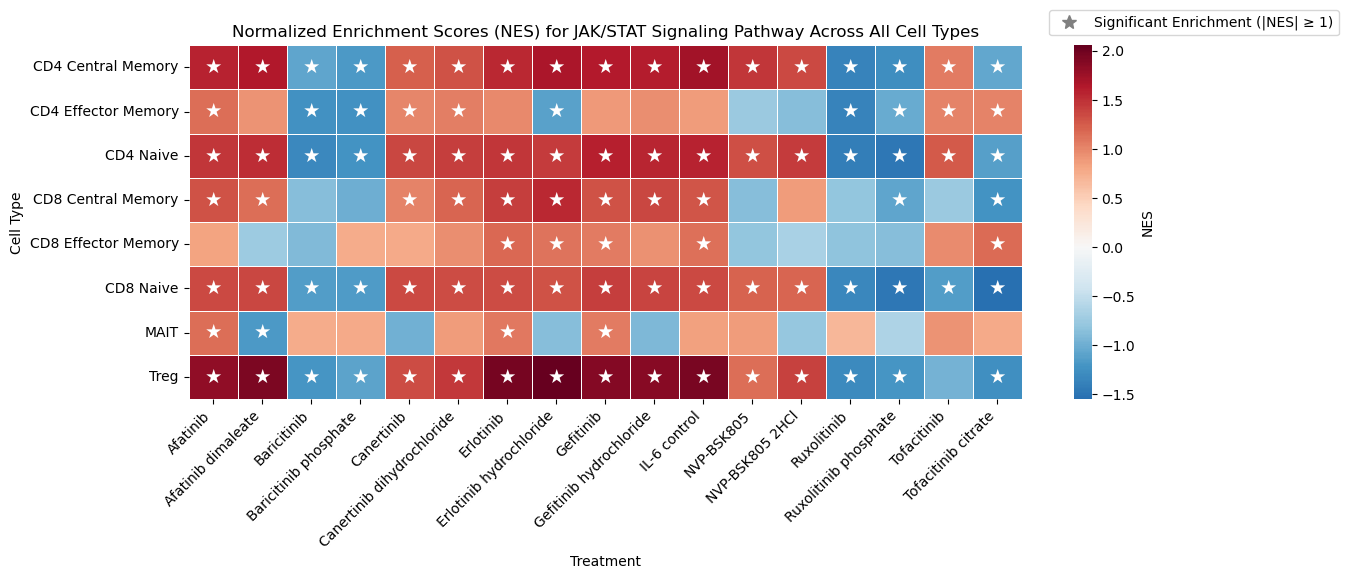

In [20]:
# Plot the heatmap
plt.figure(figsize=(len(heatmap2_nes_matrix.columns)*0.8, 6)) # width scales with # of drugs

sns.heatmap(
    heatmap2_nes_matrix,
    center=0,
    cmap="RdBu_r",
    linewidths=0.5,
    cbar_kws={"label": "NES"},
    annot = False,
    square = False
)

# Annotate NES values <= -1 and >= 1
# loop over every cell in heatmap first
for i, pathway in enumerate(heatmap2_nes_matrix.index):
    for j, drug in enumerate(heatmap2_nes_matrix.columns):
        nes_value = heatmap2_nes_matrix.loc[pathway, drug] # pull out NES value for a specific cell using particular labels (loc)
        if np.isfinite(nes_value) and abs(nes_value) >= 1:
            # extract plot axes first,
            # then position the text in the center of the cell
            plt.gca().text(j + 0.5, i + 0.5, "★", ha='center', va='center', color='white', fontsize=14)

# Add a legend for starred NES values
legend_elements = [
    Line2D([0], [0], marker="*", color="gray", linestyle="None", markersize=10,
    label="Significant Enrichment (|NES| ≥ 1)")
]

plt.gca().legend(handles=legend_elements,
                 loc="upper right",
                 bbox_to_anchor = (1.38, 1.1),
                 borderaxespad = 0,
                 frameon = True)
    
# Fix up the plot
plt.title("Normalized Enrichment Scores (NES) for JAK/STAT Signaling Pathway Across All Cell Types") # label JAK-STAT as JAK/STAT
plt.ylabel("Cell Type")
plt.xlabel("Treatment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Single pathway visualization: Gene rank vs. Enrichment score plots

In [21]:
# GSEA plot for a single pathway:
terms = pre_res.res2d.Term
# axs = pre_res.plot(terms=terms[1]) # v1.0.5

# to make more control on the plot, use
# from gseapy import gseaplot
# gseaplot(rank_metric=pre_res.ranking, term=terms[0], ofname='your.plot.pdf', **pre_res.results[terms[0]])

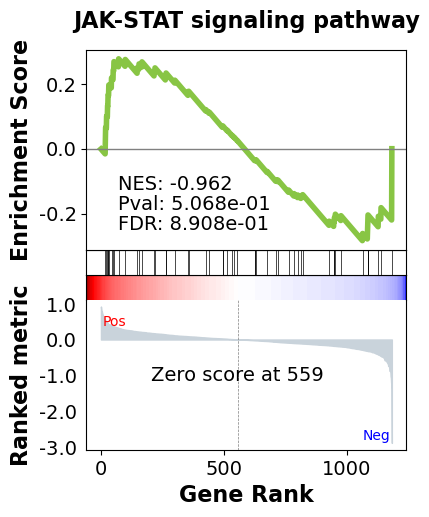

In [22]:
# GSEA plot for one pathway only:
axs = pre_res.plot(terms="JAK-STAT signaling pathway")

**With so many cell types and so many drugs, this kind of plot may be too general. So let's do something different with the enrichment score plots!**

### Single pathway visualization: Gene rank vs. Enrichment score plots: zooming in on certain cell types, and comparing different treatments against the DMSO control

In [23]:
pathway = "JAK-STAT signaling pathway"

comparisons = [
    # (cell_type, treatment, label)
    ("CD4 Central Memory", "IL-6 control", ""),
    ("CD8 Effector Memory", "IL-6 control", ""),

    ("CD4 Central Memory", "Ruxolitinib", "(Strong inhibitor)"),
    ("CD8 Effector Memory", "Ruxolitinib", "(Strong inhibitor)"),

    ("CD4 Central Memory", "Baricitinib", "(Strong inhibitor)"),
    ("CD8 Effector Memory", "Baricitinib", "(Strong inhibitor)"),

    ("CD4 Central Memory", "Afatinib", "(Weak inhibitor)"),
    ("CD8 Effector Memory", "Afatinib", "(Weak inhibitor)"),
]

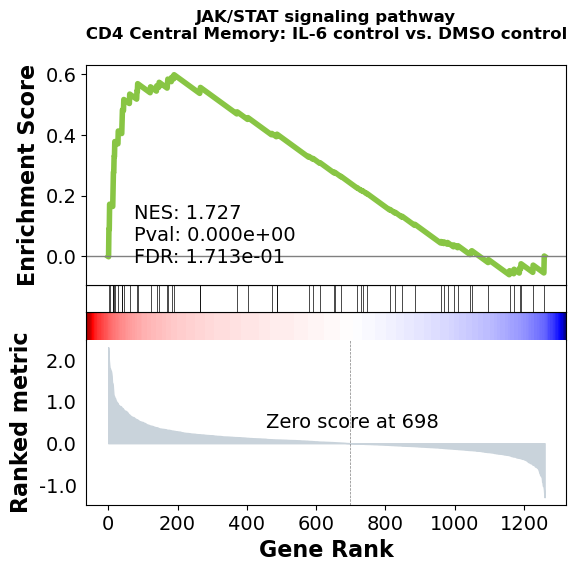

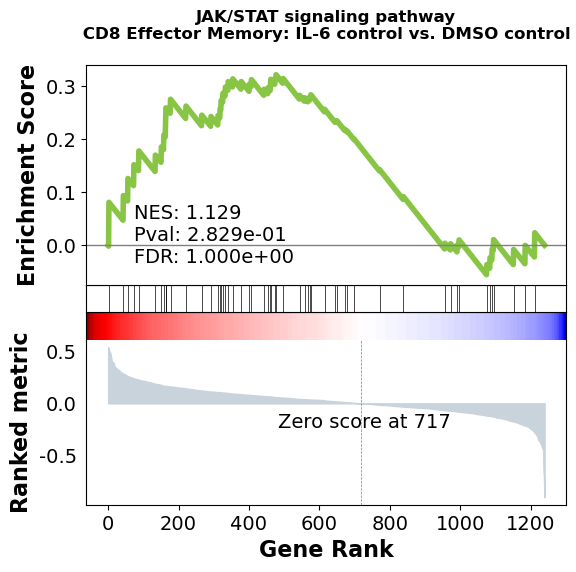

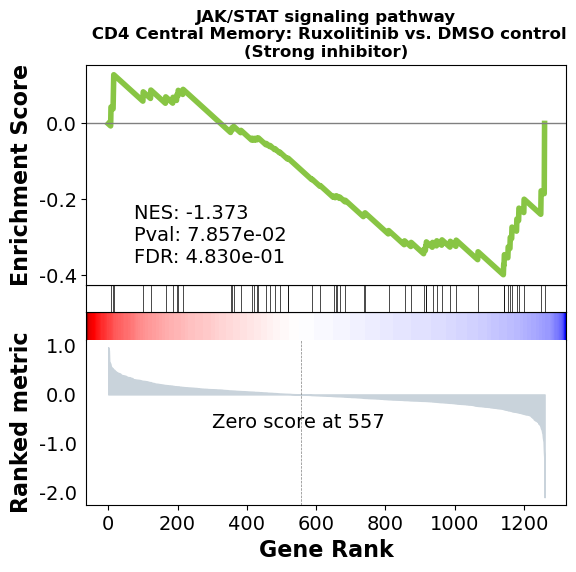

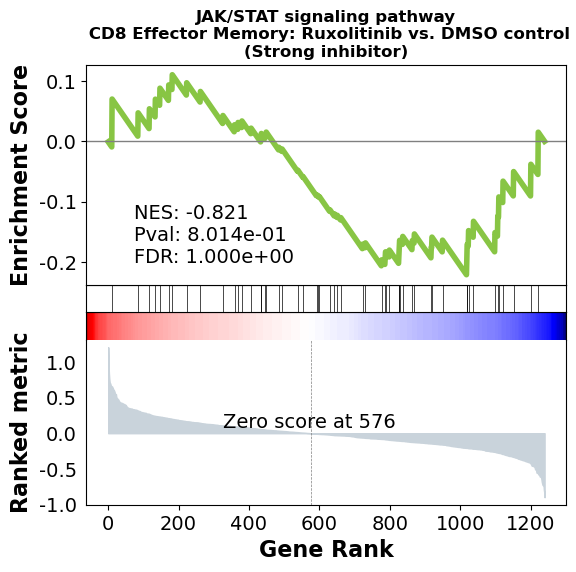

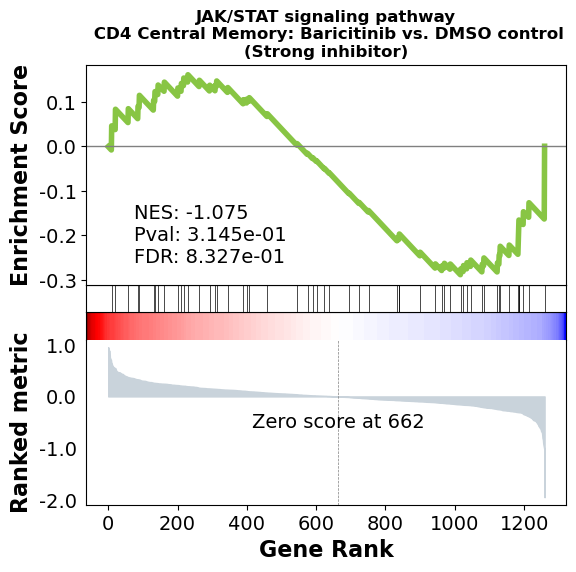

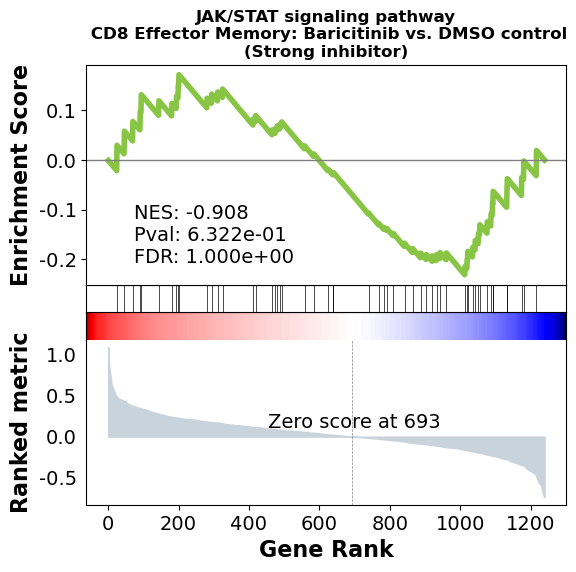

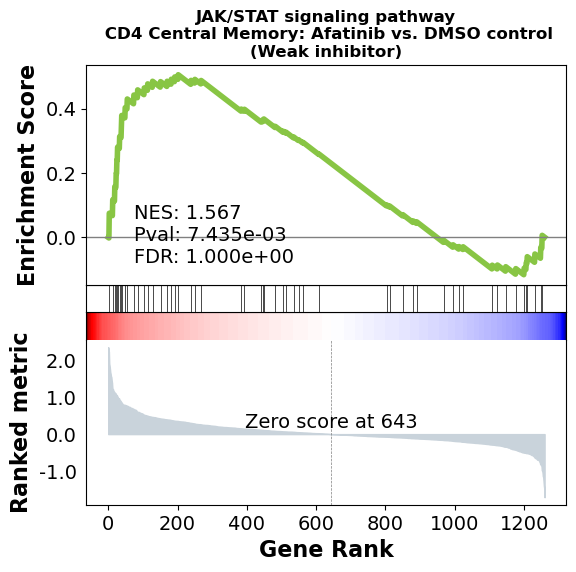

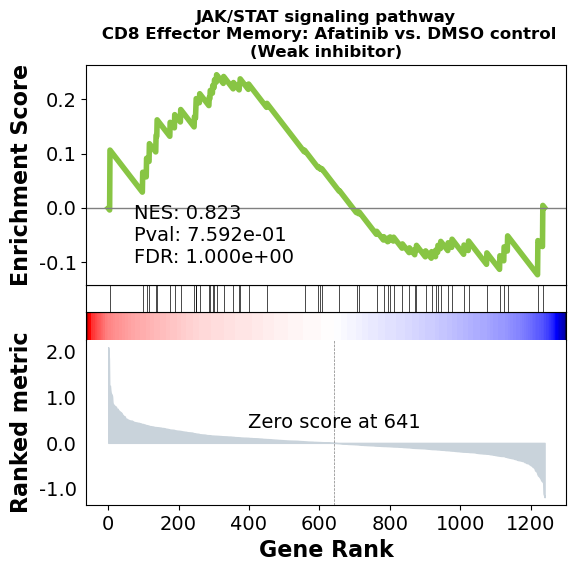

In [24]:
# from gseapy import gseaplot
# gseaplot(rank_metric=pre_res.ranking, 
# term=terms[0], 
# ofname='your.plot.pdf', 
# **pre_res.results[terms[0]])

from gseapy import gseaplot

for cell_type, drug, label in comparisons:

    pre_res = gsea_res[cell_type][drug]
    
    axs = gseaplot(
        rank_metric=pre_res.ranking,
        term=pathway,
        **pre_res.results[pathway]
    )

    # Remove the default gseaplot title!
    axs[0].set_title("")

    # Get the figure object
    fig = axs[0].get_figure()

    # Add a visible figure-level title
    fig.suptitle(
        f"JAK/STAT signaling pathway\n {cell_type}: {drug} vs. DMSO control {label}", # Change KEGG JAK/STAT pathway name from JAK-STAT to JAK/STAT
        fontsize=12,
        fontweight="bold",
        y=1.00
    )

- use `enrichment_map` to build network
- save the `nodes` and `edges`. They could be used for `cytoscape` visualization.

In [27]:
# from gseapy import enrichment_map
# # return two dataframes
# nodes, edges = enrichment_map(pre_res.res2d)

# # seems like this set didn't have anything for default cutoffs = 0.05, set it higher in enrichment_map() 

In [28]:
# import networkx as nx

In [29]:
# # build graph
# G = nx.from_pandas_edgelist(edges,
#                             source='src_idx',
#                             target='targ_idx',
#                             edge_attr=['jaccard_coef', 'overlap_coef', 'overlap_genes'])

In [30]:
# fig, ax = plt.subplots(figsize=(8, 8))

# # init node cooridnates
# pos=nx.layout.spiral_layout(G)
# #node_size = nx.get_node_attributes()
# # draw node
# nx.draw_networkx_nodes(G,
#                        pos=pos,
#                        cmap=plt.cm.RdYlBu,
#                        node_color=list(nodes.NES),
#                        node_size=list(nodes.Hits_ratio *1000))
# # draw node label
# nx.draw_networkx_labels(G,
#                         pos=pos,
#                         labels=nodes.Term.to_dict())
# # draw edge
# edge_weight = nx.get_edge_attributes(G, 'jaccard_coef').values()
# nx.draw_networkx_edges(G,
#                        pos=pos,
#                        width=list(map(lambda x: x*10, edge_weight)),
#                        edge_color='#CDDBD4')
# plt.show()

# Create data frame, data frame to CSV, upload to HISE

In [31]:
# empty list
all_results = []

# results table: pre_res.res2d already stores all scores

for cell_type, drug_dict in gsea_res.items():
    for drug, pre_res in drug_dict.items():
        res = pre_res.res2d # results in rows with columns like Term, NES, FDR q-val, etc...

        # Add more columns for detail
        res["cell_type"] = cell_type
        res["drug"] = drug
        res["comparison"] = f"{drug} vs. DMSO control"
        res["gene_set"] = "KEGG"   # Hallmark, KEGG, or Reactome

        # Add to dataframe
        all_results.append(res)

# Create a data frame
gseapy_KEGG_results_df = pd.concat(all_results)

In [32]:
gseapy_KEGG_results_df

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,cell_type,drug,comparison,gene_set
0,prerank,"Parathyroid hormone synthesis, secretion and a...",-0.64302,-1.927566,0.0,0.029764,0.027,13/20,24.52%,RXRA;GNA11;GATA3;MAP2K1;BCL2;EGR1;PLCB3;CREB1;...,CD4 Central Memory,IL-6 control,IL-6 control vs. DMSO control,KEGG
1,prerank,JAK-STAT signaling pathway,0.597703,1.727226,0.0,0.171271,0.133,20/55,15.16%,IL2RB;MYC;STAT3;JAK3;SOCS1;IL2RA;STAT1;IL12RB2...,CD4 Central Memory,IL-6 control,IL-6 control vs. DMSO control,KEGG
2,prerank,Rheumatoid arthritis,-0.506225,-1.547398,0.042969,0.414498,0.403,10/23,13.25%,IL23A;ITGAL;CD80;CSF1;TNF;JUN;TGFB3;TGFB1;LTB;...,CD4 Central Memory,IL-6 control,IL-6 control vs. DMSO control,KEGG
3,prerank,Chemokine signaling pathway,0.513595,1.502241,0.011521,1.0,0.751,17/65,14.05%,VAV1;STAT3;JAK3;STAT1;STAT2;CXCR6;CCR5;CCL27;C...,CD4 Central Memory,IL-6 control,IL-6 control vs. DMSO control,KEGG
4,prerank,Malaria,-0.540315,-1.493267,0.032573,0.392083,0.498,7/15,11.35%,CD40LG;ITGAL;CR1;TNF;TGFB3;TGFB1;PECAM1,CD4 Central Memory,IL-6 control,IL-6 control vs. DMSO control,KEGG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,prerank,Type II diabetes mellitus,-0.206653,-0.538626,0.972414,1.0,1.0,7/15,34.51%,PIK3CA;SOCS1;SOCS2;PRKCE;MAPK1;PIK3CD;MAPK9,Treg,Tofacitinib,Tofacitinib vs. DMSO control,KEGG
135,prerank,B cell receptor signaling pathway,-0.156547,-0.499147,1.0,1.0,1.0,7/38,22.53%,NFKBIB;CD79B;PIK3CA;MALT1;BCL10;CD81;CHUK,Treg,Tofacitinib,Tofacitinib vs. DMSO control,KEGG
136,prerank,Alcoholism,0.161373,0.489584,0.995444,0.996486,1.0,20/20,84.14%,RAF1;HRAS;BRAF;HAT1;CREB1;PRKACA;NRAS;SHC1;GNB...,Treg,Tofacitinib,Tofacitinib vs. DMSO control,KEGG
137,prerank,Ras signaling pathway,-0.144119,-0.483707,0.998387,1.0,1.0,17/50,35.36%,PIK3CA;CSF1;TIAM1;ELK1;LAT;PAK4;RASA1;CHUK;FLT...,Treg,Tofacitinib,Tofacitinib vs. DMSO control,KEGG


In [33]:
gseapy_KEGG_results_df.to_csv('il6_jak-stat_paired-form_gseapy_kegg.csv') # il6_jak-stat_paired-form_gseapy_kegg.csv

In [34]:
uuid_list = [
    '02765813-6130-4fac-8708-f01768aa05b6',
    '06b73fab-62d2-4fc3-8a86-2df960cbc1ea',
    '1aecccab-f62a-4c49-b2fe-ba5777930262',
    '207c5f6c-92ec-4690-a7fd-07b0cbebd9f6',
    '3adc31cf-1ea9-4a7d-bc63-31358cb8a325',
    '45e4bd43-4fae-49df-8974-8d043e395f73',
    '4c13d814-1493-48f8-8021-a819b556e97b',
    '56bc5070-2968-4c6b-8198-4e997c75e4fe',
    '64e7735c-e89b-41ef-a293-a39b9ed5ade9',
    '72755c82-880d-4814-8322-6a81ed07466d',
    '9693f71c-dcb3-4d40-b2ad-74fc2ad147de',
    '9f37360e-0191-418b-ab51-fdb86ab9be09',
    'a3bc4704-5fe3-4a74-bce5-0700689db1f6',
    'af42c180-0218-4918-ae12-0a4f43c4aa1f',
    'b790716c-b2de-4028-ad60-1e5a7b81f05d',
    'bfa4c2f1-69d5-4bcf-a1a6-9beb69dbffc9',
    'd076758f-3d76-49b7-91be-0217eefcdf26',
    'd2f8da49-85eb-4dea-a166-5308bb73de91'
]

file_list = hisepy.cache_files(uuid_list)

In [35]:
# a function to make unique destination strings using the periodic table elements
def element_id(n = 3):
    import periodictable
    from random import randrange
    rand_el = []
    
    for i in range(n):
        el = randrange(0,118)
        rand_el.append(periodictable.elements[el].name)
        
    rand_str = '-'.join(rand_el)
    return rand_str

In [36]:
# getting unique title for upload, using UTC time
from datetime import datetime, timezone

# getting the current time and saving it
utc_current = datetime.now(timezone.utc)
print(utc_current)

# listing the files to upload
files_to_upload = [
    "il6_jak-stat_paired-form_gseapy_kegg.csv"
]

# uploading the files
hisepy.upload_files(
    files = files_to_upload,
    study_space_id = "c8a94b84-b0b7-40a9-980b-81a63ad6e115",
    title = f"GSEApy_KEGG_data_h5ad_{utc_current}",
    input_file_ids = uuid_list,
    #destination is randomly generated elements
    destination = element_id()
)

2026-03-04 07:53:07.532302+00:00
checking if conda environment can compile...
creating temp conda environment...
temp conda environment created successfully, now packing...
Cannot determine the current notebook.
1) /home/workspace/gseapy_KEGG_JW.ipynb
2) /home/workspace/gseapy_Reactome_JW.ipynb
3) /home/workspace/gseapy_Hallmark_JW.ipynb
Please select (1-3) 


 1


{'Message': 'General Okay-ness',
 'VisualizationId': '00000000-0000-0000-0000-000000000000',
 'AbstractionId': '00000000-0000-0000-0000-000000000000',
 'TraceId': 'bb975e1d-6dbc-486f-9073-426f3b857b21',
 'ProcessId': 'c25d919e-cd02-4fd9-bf41-3cd3ca73afa9',
 'WorkflowId': '54e00d4a-f453-4b27-8d4e-aeb409cfd9bd',
 'FileIds': ['35c87f69-196c-4da4-a374-6d772a617c67']}

- 11/17/2025
- Edited 11/21/2025 with input from Lucas, and updated DEG portion.
- Edited 11/25/2025 to add notes and work on other visualizations.
- Edited 12/14/2025 to fix up "Normalization" section, add in "Cleaning up labels" section, update DEG section.
- Edited 12/16/2025 to create three separate notebooks for each gene set, and to begin visualizing heatmaps and gene rank vs. enrichment score plots.
- Edited 01/10-12/2026 to adjust heatmaps and create separate gene rank vs. enrichment score plots. Notes also kept on a [Google Doc](https://docs.google.com/document/d/1lY_UYWN1yy6c9lvWzDPkuWC5koT6x5sYsxzeHm_vOkk/edit?usp=sharing).
- Edited 01/14/2026 to fix annotations on heatmaps.
- Edited 01/20/2026 to filter genes to keep only those that are expressed in 1% or more of the cells for each cell type before DEG tests, and fixed up labels. Created data frame, converted it to a csv, and uploaded to HISE.
- Edited 01/21/2026 to keep only genes that are epressed in 2% or more of the cells for each cell type.
- Edited 01/22/2026 to add code that color-coordinates drugs.